#📈 Stock Market Forecasting with LSTM ( Mercados bursátiles Netflix)
Predictive modeling of financial assets using Deep Learning.

##📋 Overview
Este proyecto implementa una red neuronal de Memoria a Corto y Largo Plazo (LSTM) para predecir el comportamiento del mercado bursátil. El objetivo principal es evaluar la capacidad del modelo para generar pronósticos en diferentes horizontes temporales, ajustando las ventanas de entrada (input steps) y salida (output steps).

## Link data
https://www.tradingview.com/

##📊 Data Source & Features
Los datos se extraen en tiempo real utilizando la librería **yfinance**, enfocándose en activos financieros globales (excluyendo AAPL para diversificación de análisis).
* Date: La fecha correspondiente a cada registro.
* Open: El precio de apertura de la acción en la fecha especificada.
* High: El precio más alto al que se negoció la acción durante la fecha especificada.
* Low: El precio más bajo al que se negoció la acción durante la fecha especificada.
* Close: El precio de cierre de la acción en la fecha especificada. Este es el precio que más se utiliza para los análisis y predicciones.
* Adj Close: El precio de cierre ajustado. Este precio ajusta el precio de cierre de acuerdo a eventos corporativos como dividendos, divisiones de acciones y nuevas emisiones de acciones, proporcionando una visión más precisa del valor real de la acción.
* Volume: El número de acciones negociadas durante la fecha especificada.

In [ ]:
# Importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import yfinance as yf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, LSTM
from keras.callbacks import EarlyStopping

## Descargar datos

In [ ]:
# Descargar datos de la acción Netflix
datos_netflix = yf.download('NFLX', start='2015-01-01', end='2025-12-31', auto_adjust=False)
# El nombre de la acción lo puede encontrar en https://www.tradingview.com/

# Visualizar los primeros 10 datos
datos_netflix.head(10)

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,NFLX,NFLX,NFLX,NFLX,NFLX,NFLX
Date,,,,,,
2015-01-02,4.984857,4.984857,5.033143,4.873143,4.915143,134750000
2015-01-05,4.731143,4.731143,4.925857,4.714714,4.925857,181650000
2015-01-06,4.650143,4.650143,4.764000,4.566143,4.734714,160377000
2015-01-07,4.674286,4.674286,4.742143,4.627143,4.734714,98497000
2015-01-08,4.778000,4.778000,4.783571,4.647857,4.712000,96019000
2015-01-09,4.704143,4.704143,4.802000,4.689857,4.763143,95781000
2015-01-12,4.554714,4.554714,4.719857,4.526429,4.709000,129444000
2015-01-13,4.625571,4.625571,4.704857,4.590000,4.602143,187215000


In [ ]:
datos_netflix.tail(10)

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,NFLX,NFLX,NFLX,NFLX,NFLX,NFLX
Date,,,,,,
2025-12-16,94.570000,94.570000,94.930000,93.320000,93.879997,34265000
2025-12-17,94.790001,94.790001,97.330002,94.459999,95.980003,50472800
2025-12-18,94.000000,94.000000,95.809998,93.589996,95.019997,37244700
2025-12-19,94.389999,94.389999,95.540001,93.449997,93.570000,78990200
2025-12-22,93.230003,93.230003,94.709999,92.910004,94.709999,39484800
2025-12-23,93.500000,93.500000,93.809998,91.330002,93.400002,25896200
2025-12-24,93.639999,93.639999,93.680000,92.669998,93.110001,12427900
2025-12-26,94.470001,94.470001,94.690002,93.269997,93.480003,22068300


In [ ]:
datos_netflix.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2765 entries, 2015-01-02 to 2025-12-30
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Adj Close, NFLX)  2765 non-null   float64
 1   (Close, NFLX)      2765 non-null   float64
 2   (High, NFLX)       2765 non-null   float64
 3   (Low, NFLX)        2765 non-null   float64
 4   (Open, NFLX)       2765 non-null   float64
 5   (Volume, NFLX)     2765 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 151.2 KB


In [ ]:
datos_netflix.describe()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,NFLX,NFLX,NFLX,NFLX,NFLX,NFLX
count,2765.000000,2765.000000,2765.000000,2765.000000,2765.000000,2.765000e+03
mean,40.458456,40.458456,41.020164,39.862249,40.448699,8.467612e+07
std,28.609884,28.609884,28.923861,28.265063,28.605462,7.797353e+07
min,4.554714,4.554714,4.678571,4.526429,4.602143,1.144000e+07
25%,18.097000,18.097000,18.400000,17.754999,18.100000,3.930100e+07
50%,35.113998,35.113998,35.703999,34.520000,35.099998,6.142600e+07
75%,52.070000,52.070000,52.683998,51.297001,51.973000,1.016120e+08
max,133.912994,133.912994,134.115005,132.121002,133.822998,1.333875e+09


## Preparación de los Datos
Para realizar una predicción de series de tiempo, nos enfocaremos en la columna `Close` (precio de cierre), ya que es la que más comúnmente se utiliza para este tipo de análisis.

Escalaremos los datos, y se divide en datos de entrenamiento, validación y prueba.

In [ ]:
# Preparar los datos
# Elegir la columna de "close"
precio_cierre = datos_netflix["Close"].values.reshape(-1, 1)
precio_cierre

array([[ 4.98485708],
       [ 4.731143  ],
       [ 4.65014315],
       ...,
       [94.47000122],
       [94.15000153],
       [93.77999878]])

In [ ]:
# Escalar los datos
scaler= StandardScaler()
precio_cierre_escalado = scaler.fit_transform(precio_cierre)
precio_cierre_escalado

array([[-1.24013139],
       [-1.24900106],
       [-1.25183275],
       ...,
       [ 1.88820464],
       [ 1.87701768],
       [ 1.86408265]])

In [ ]:
# Crear conjuntos de entrenamiento 70%, validación 15% y prueba 15%
# Realizamos un split secuencial manual para garantizar que el conjunto de validación y prueba
# sean cronológicamente posteriores al entrenamiento, evitando el sesgo de información del futuro.
size= len(precio_cierre_escalado)
train_size = int(0.7 * size)
val_size = int(0.15 * size)
test_size = size - train_size - val_size

# Crear conjuntos de entrenamiento, validación y prueba
train_set = precio_cierre_escalado[:train_size]
val_set = precio_cierre_escalado[train_size:train_size+val_size]
test_set = precio_cierre_escalado[train_size+val_size:]

# es posible tambien igual usar time series split con shuffle= False
# Imprimimos
print(len(train_set))
print(len(val_set))
print(len(test_set))

1935
414
416


### Función que divide la serie de tiempo en pasos de entrada y salida
Vamos a crear una función que prepare los datos para ser utilizados en un modelo de predicción de series de tiempo.

In [ ]:
def crear_dataset(data, time_step=1, step_salida=1):
    X, y = [], []
    for i in range(len(data) - time_step - step_salida + 1):
        X.append(data[i:(i + time_step), 0])
        y.append(data[(i + time_step):(i + time_step + step_salida), 0])
    return np.array(X), np.array(y)

## Probar con diferentes ventanas de tiempo de de entrada y salida

In [ ]:
# Crear dataset con una ventana de tiempo de 5 días
time_step = 5
X_train_, y_train = crear_dataset(train_set, time_step)
X_val_, y_val = crear_dataset(val_set, time_step)

Debemos redimensionar los datos para que sean compatibles con la entrada de LSTM `[samples, time steps, features]`

In [ ]:
X_train = X_train_.reshape(X_train_.shape[0], X_train_.shape[1], 1)
X_val = X_val_.reshape(X_val_.shape[0], X_val_.shape[1], 1)
X_train[0]

array([[-1.24013139],
       [-1.24900106],
       [-1.25183275],
       [-1.25098874],
       [-1.24736297]])

In [ ]:
y_train[0]

array([-1.24994495])

In [ ]:
print(X_train.shape)
print(y_train.shape)
print(X_val.shape)
print(y_val.shape)

(1930, 5, 1)
(1930, 1)
(409, 5, 1)
(409, 1)


## Creación del modelo LSTM

In [ ]:
# Crear un modelo con celdas LSTM
# Probemos con un modelo con 2 capas con 50 celdas LSTM
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(time_step, 1)))
model.add(LSTM(50, return_sequences=False))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Compilar el modelo

model.compile(optimizer='adam', loss='mean_squared_error')
# Entrenar el modelo
# Implementamos una parada temprana 'early_stopping' para evitar sobreajuste
early_stopping = EarlyStopping(patience=10, restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=1,
           validation_data=(X_val, y_val), callbacks=[early_stopping])

Epoch 1/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.1839 - val_loss: 0.0048
Epoch 2/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0039 - val_loss: 0.0037
Epoch 3/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0029 - val_loss: 0.0035
Epoch 4/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0028 - val_loss: 0.0035
Epoch 5/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0034 - val_loss: 0.0034
Epoch 6/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0030 - val_loss: 0.0034
Epoch 7/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0028 - val_loss: 0.0034
Epoch 8/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0030 - val_loss: 0.0035
Epoch 9/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0025 - val_loss: 0.0033
Epoch 10/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0027 - val_loss: 0.0034
Epoch 11/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0028 - val_loss: 0.0032
Epoch 12/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 5, 50)          │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91,955 (359.20 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 61,304 (239.47 KB)

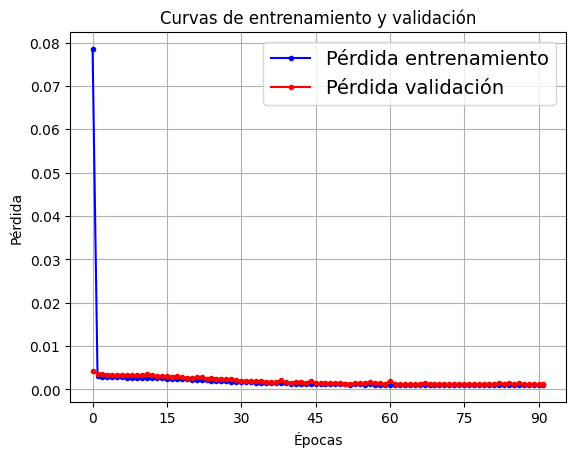

In [ ]:
def plot_learning_curves(loss, val_loss):
     plt.plot(np.arange(len(loss)), loss, "b.-", label="Pérdida entrenamiento")
     plt.plot(np.arange(len(val_loss)), val_loss, "r.-", label="Pérdida validación")
     plt.gca().xaxis.set_major_locator(mpl.ticker.MaxNLocator(integer=True))
     plt.legend(fontsize=14)
     plt.xlabel("Épocas")
     plt.ylabel("Pérdida")
     plt.title("Curvas de entrenamiento y validación")
     plt.grid(True)

plot_learning_curves(history.history["loss"], history.history["val_loss"])
plt.show()

## Realizamos predicciones en el conjunto de prueba

In [ ]:
# Realizar predicciones
X_test, y_test = crear_dataset(test_set, time_step)
y_pred = model.predict(X_test)

# Invertir la normalización para obtener los valores reales
y_pred = scaler.inverse_transform(y_pred)
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step


In [ ]:
# Calcular RMSE y MAE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print('Root mean square error: ', rmse)
print('Mean absolute error: ', mae)


Root mean square error:  4.151598130483217
Mean absolute error:  3.0955179590378363


Visualicemos los resultados

In [ ]:
# Predicción en el conjunto de entrenamiento para visualización
y_pred_train = model.predict(X_train_)
y_pred_train = scaler.inverse_transform(y_pred_train)

# Predicción en el conjunto de validación para visualización
y_pred_val = model.predict(X_val_)
y_pred_val = scaler.inverse_transform(y_pred_val)

61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


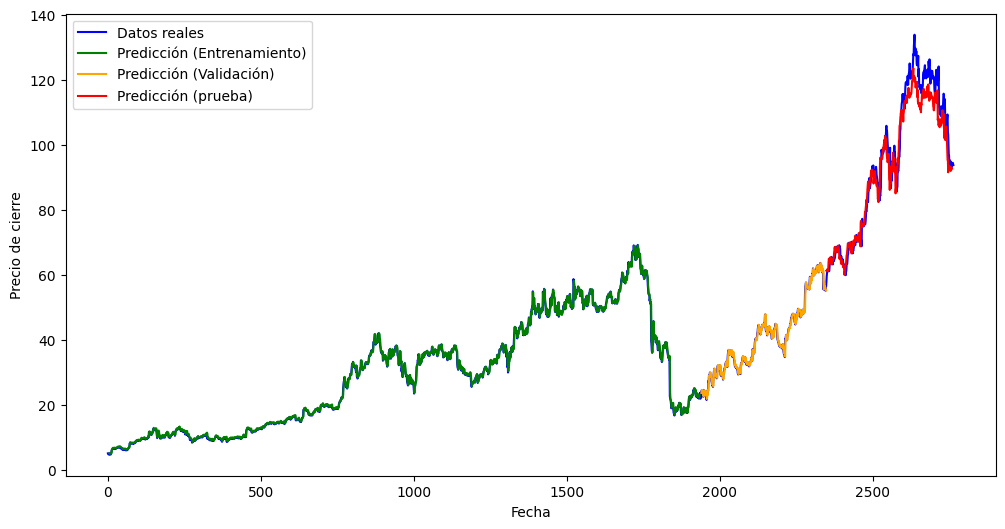

In [ ]:
# Longitud de los datos de entrenamiento y validación
len_train = len(train_set)
len_val = len(val_set)

# Ajustar 'x' para que coincida con la longitud de 'precio_cierre'
x = np.arange(len(precio_cierre))

plt.figure(figsize=(12, 6))
plt.plot(x, precio_cierre, 'b', label='Datos reales')
plt.plot(x[time_step:time_step + len(y_pred_train)], y_pred_train, 'g', label='Predicción (Entrenamiento)')
plt.plot(x[len(train_set) + time_step:len(train_set) + time_step + len(y_pred_val)], y_pred_val, 'orange', label='Predicción (Validación)')
plt.plot(x[len_train + len_val:len_train + len_val + len(y_pred)], y_pred, 'r', label='Predicción (prueba)')
plt.xlabel('Fecha')
plt.ylabel('Precio de cierre')
plt.legend()
plt.show()